In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

process = Path("../Data/Processed")
figure = Path("../Reports/Figure")
# Load the cleaned sales dataset
sales_df = pd.read_csv(process / "retail_sales_cleaned.csv",parse_dates=["InvoiceDate"])

print("Sales dataset shape:",sales_df.shape)
print("\nColumns:",sales_df.columns.tolist())
print("\nDate range:")
print(sales_df["InvoiceDate"].min()," to ",sales_df["InvoiceDate"].max())

Sales dataset shape: (779425, 10)

Columns: ['Invoice', 'InvoiceDate', 'CustomerID', 'StockCode', 'Description', 'Quantity', 'UnitPrice', 'Country', 'IsGuestCheckout', 'TotalPrice']

Date range:
2009-12-01 07:45:00  to  2011-12-09 12:50:00


In [ ]:
sales_df["Date"] = sales_df["InvoiceDate"].dt.normalize()

print("Date column created.")
sales_df.head()

Date column created.


,InvoiceDate,Date
0,2009-12-01 07:45:00,2009-12-01
1,2009-12-01 07:45:00,2009-12-01
2,2009-12-01 07:45:00,2009-12-01
3,2009-12-01 07:45:00,2009-12-01
4,2009-12-01 07:45:00,2009-12-01


In [6]:
daily_df = (sales_df.groupby("Date",as_index=False)
    .agg(
        DailyRevenue=("TotalPrice","sum"),
        DailyQuantity=("Quantity","sum"),
        DailyOrders=("Invoice","nunique"),
        DailyCustomers=("CustomerID","nunique")
    )
)

print("Daily dataset shape:",daily_df.shape)
daily_df.head()

Daily dataset shape: (604, 5)


,Date,DailyRevenue,DailyQuantity,DailyOrders,DailyCustomers
0,2009-12-01,43894.87,24335,98,91
1,2009-12-02,52762.06,29679,110,94
2,2009-12-03,67413.62,48009,122,106
3,2009-12-04,33913.81,19954,80,76
4,2009-12-05,9803.05,5119,30,26


In [7]:
full_dates = pd.DataFrame({"Date":pd.date_range(start=daily_df["Date"].min(),end=daily_df["Date"].max(),freq="D")})

daily_df = full_dates.merge(daily_df,on="Date",how="left")

print("Shape after adding missing dates:",daily_df.shape)
print("\nMissing values:")
print(daily_df.isnull().sum())

Shape after adding missing dates: (739, 5)

Missing values:
Date                0
DailyRevenue      135
DailyQuantity     135
DailyOrders       135
DailyCustomers    135
dtype: int64


In [9]:
missing_dates = daily_df[daily_df["DailyRevenue"].isna()][["Date"]].copy()
missing_dates["DayName"] = missing_dates["Date"].dt.day_name()

print("Missing calendar dates:",missing_dates.shape[0])

print("\nMissing dates by day:")
print(missing_dates["DayName"].value_counts())

Missing calendar dates: 135

Missing dates by day:
DayName
Saturday     104
Monday        11
Friday         7
Sunday         6
Thursday       3
Tuesday        2
Wednesday      2
Name: count, dtype: int64


In [ ]:
daily_df[["DailyRevenue","DailyQuantity","DailyOrders","DailyCustomers"]] = daily_df[["DailyRevenue","DailyQuantity","DailyOrders","DailyCustomers"]].fillna(0)
daily_df[["DailyQuantity","DailyOrders","DailyCustomers"]] = daily_df[["DailyQuantity","DailyOrders","DailyCustomers"]].astype(int)

print("\nMissing values:")
print(daily_df.isnull().sum())


Missing values:
Date              0
DailyRevenue      0
DailyQuantity     0
DailyOrders       0
DailyCustomers    0
dtype: int64


In [22]:
# shift(1) moves every value in a column down by one row
# rolling(7) calculates the average of that backward looking window of 7 days

daily_df["Revenue_MA7"] = daily_df["DailyRevenue"].shift(1).rolling(7).mean()
daily_df["Revenue_MA30"] = daily_df["DailyRevenue"].shift(1).rolling(30).mean()

daily_df["Quantity_MA7"] = daily_df["DailyQuantity"].shift(1).rolling(7).mean()
daily_df["Quantity_MA30"] = daily_df["DailyQuantity"].shift(1).rolling(30).mean()

daily_df.sample(10)

,Date,DailyRevenue,DailyQuantity,DailyOrders,DailyCustomers,Revenue_MA7,Revenue_MA30,Quantity_MA7,Quantity_MA30
495,2011-04-10,9879.75,5603,32,31,16670.072857,18190.602333,9146.857143,10702.066667
474,2011-03-20,19880.99,13473,57,56,17415.150000,16720.896000,10351.714286,9753.600000
437,2011-02-11,18579.96,9575,38,34,12161.447143,17621.394333,6918.857143,11022.766667
491,2011-04-06,12698.32,8011,37,36,20595.831429,19358.249333,12420.857143,11409.800000
348,2010-11-14,27934.71,16462,86,76,40874.111571,33651.664367,22283.285714,18679.233333
390,2010-12-26,0.00,0,0,0,7621.780000,24647.578000,4921.285714,13440.633333
726,2011-11-27,16969.25,10307,56,51,37272.531429,36738.873000,21398.285714,21181.500000
725,2011-11-26,0.00,0,0,0,37272.531429,38597.113000,21398.285714,22262.100000
285,2010-09-12,15528.75,9278,48,46,16584.557143,18470.860000,9971.428571,11998.900000
222,2010-07-11,7609.23,5711,26,24,19934.597143,19428.491667,10105.142857,11356.466667


In [23]:
daily_df["Revenue_Lag1"] = daily_df["DailyRevenue"].shift(1)
daily_df["Revenue_Lag7"] = daily_df["DailyRevenue"].shift(7)
daily_df["Revenue_Lag30"] = daily_df["DailyRevenue"].shift(30)

daily_df["Quantity_Lag1"] = daily_df["DailyQuantity"].shift(1)
daily_df["Quantity_Lag7"] = daily_df["DailyQuantity"].shift(7)
daily_df["Quantity_Lag30"] = daily_df["DailyQuantity"].shift(30)

daily_df.head(35)

,Date,DailyRevenue,DailyQuantity,DailyOrders,DailyCustomers,Revenue_MA7,Revenue_MA30,Quantity_MA7,Quantity_MA30,Revenue_Lag1,Revenue_Lag7,Revenue_Lag30,Quantity_Lag1,Quantity_Lag7,Quantity_Lag30
0,2009-12-01,43894.87,24335,98,91,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-12-02,52762.06,29679,110,94,NaN,NaN,NaN,NaN,43894.87,NaN,NaN,24335.0,NaN,NaN
2,2009-12-03,67413.62,48009,122,106,NaN,NaN,NaN,NaN,52762.06,NaN,NaN,29679.0,NaN,NaN
3,2009-12-04,33913.81,19954,80,76,NaN,NaN,NaN,NaN,67413.62,NaN,NaN,48009.0,NaN,NaN
4,2009-12-05,9803.05,5119,30,26,NaN,NaN,NaN,NaN,33913.81,NaN,NaN,19954.0,NaN,NaN
5,2009-12-06,24390.10,11502,72,63,NaN,NaN,NaN,NaN,9803.05,NaN,NaN,5119.0,NaN,NaN
6,2009-12-07,33002.49,15557,94,77,NaN,NaN,NaN,NaN,24390.10,NaN,NaN,11502.0,NaN,NaN
7,2009-12-08,44763.34,22241,102,91,37882.857143,NaN,22022.142857,NaN,33002.49,43894.87,NaN,15557.0,24335.0,NaN
8,2009-12-09,30763.17,15881,77,74,38006.924286,NaN,21723.000000,NaN,44763.34,52762.06,NaN,22241.0,29679.0,NaN
9,2009-12-10,38598.21,22534,87,82,34864.225714,NaN,19751.857143,NaN,30763.17,67413.62,NaN,15881.0,48009.0,NaN


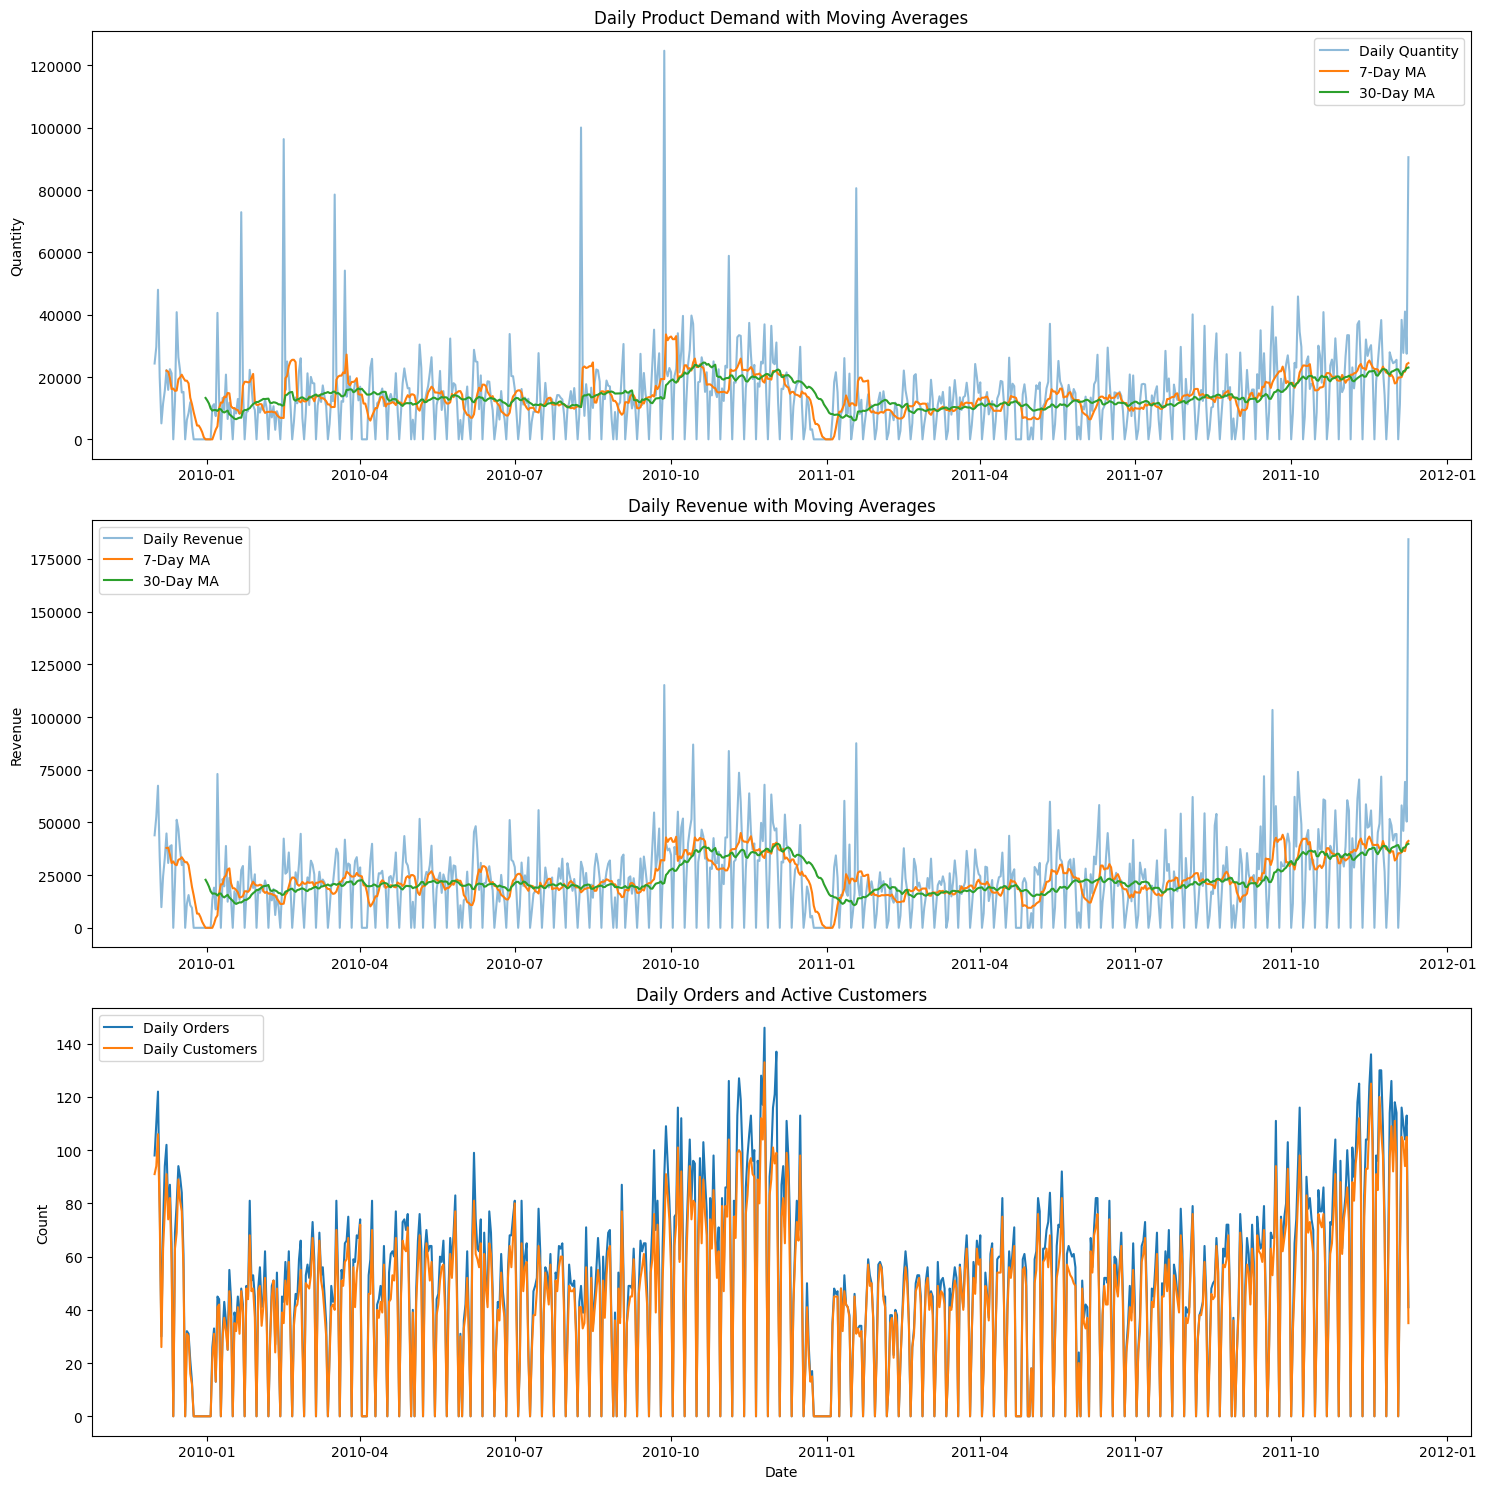

In [26]:
fig,axes = plt.subplots(3,1,figsize=(15,15))

axes[0].plot(daily_df["Date"],daily_df["DailyQuantity"],label="Daily Quantity",alpha=0.5)
axes[0].plot(daily_df["Date"],daily_df["Quantity_MA7"],label="7-Day MA")
axes[0].plot(daily_df["Date"],daily_df["Quantity_MA30"],label="30-Day MA")
axes[0].set_title("Daily Product Demand with Moving Averages")
axes[0].set_ylabel("Quantity")
axes[0].legend()

axes[1].plot(daily_df["Date"],daily_df["DailyRevenue"],label="Daily Revenue",alpha=0.5)
axes[1].plot(daily_df["Date"],daily_df["Revenue_MA7"],label="7-Day MA")
axes[1].plot(daily_df["Date"],daily_df["Revenue_MA30"],label="30-Day MA")
axes[1].set_title("Daily Revenue with Moving Averages")
axes[1].set_ylabel("Revenue")
axes[1].legend()

axes[2].plot(daily_df["Date"],daily_df["DailyOrders"],label="Daily Orders")
axes[2].plot(daily_df["Date"],daily_df["DailyCustomers"],label="Daily Customers")
axes[2].set_title("Daily Orders and Active Customers")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.savefig("../Reports/Figure/4-Daily_Sales_TimeSeries_Report.png",dpi=300,bbox_inches="tight")
plt.show()

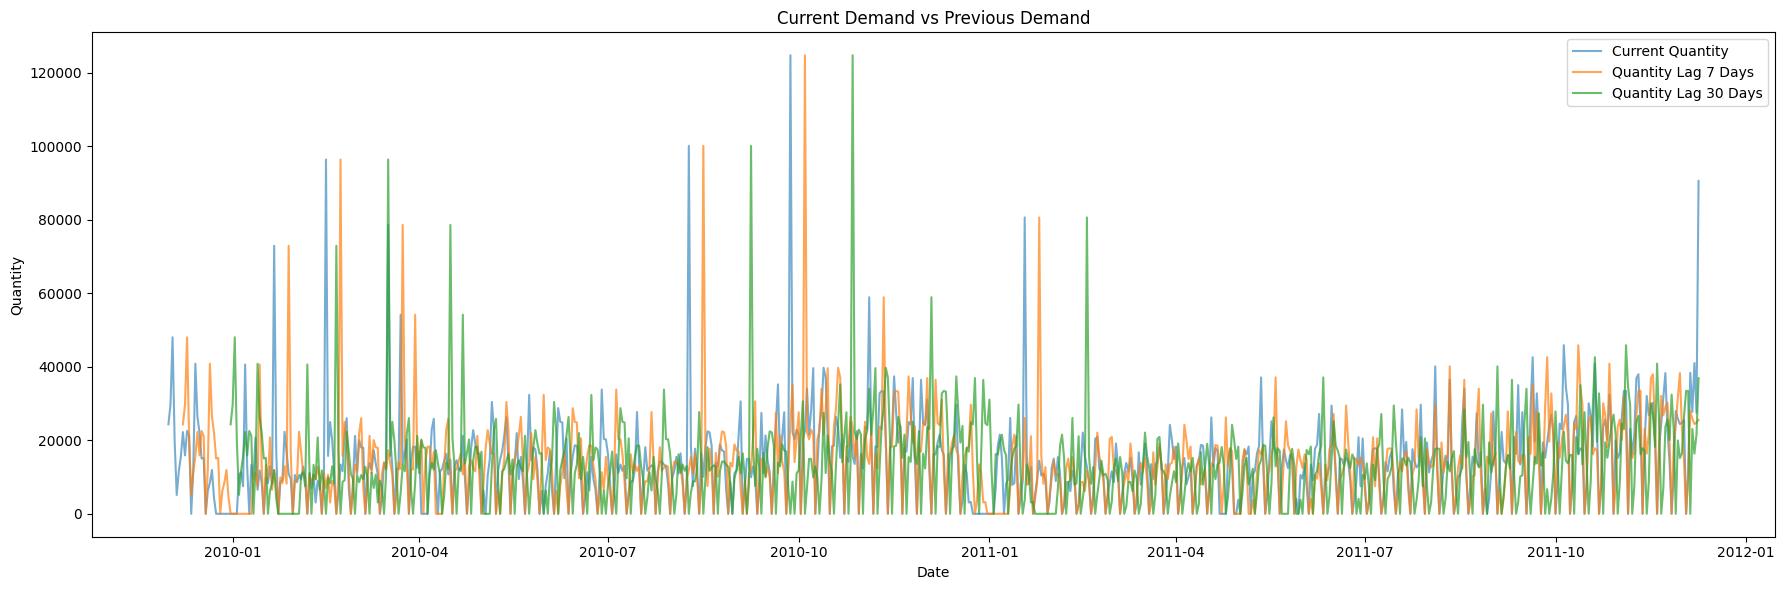

In [31]:
plt.figure(figsize=(18,6))
plt.plot(daily_df["Date"],daily_df["DailyQuantity"],label="Current Quantity",alpha=0.6)
plt.plot(daily_df["Date"],daily_df["Quantity_Lag7"],label="Quantity Lag 7 Days",alpha=0.7)
plt.plot(daily_df["Date"],daily_df["Quantity_Lag30"],label="Quantity Lag 30 Days",alpha=0.7)
plt.title("Current Demand vs Previous Demand")
plt.xlabel("Date")
plt.ylabel("Quantity")
plt.legend()
plt.tight_layout()
plt.savefig("../Reports/Figure/4-Quantity_Lag_Comparison.png",dpi=300,bbox_inches="tight")
plt.show()

## Better Version

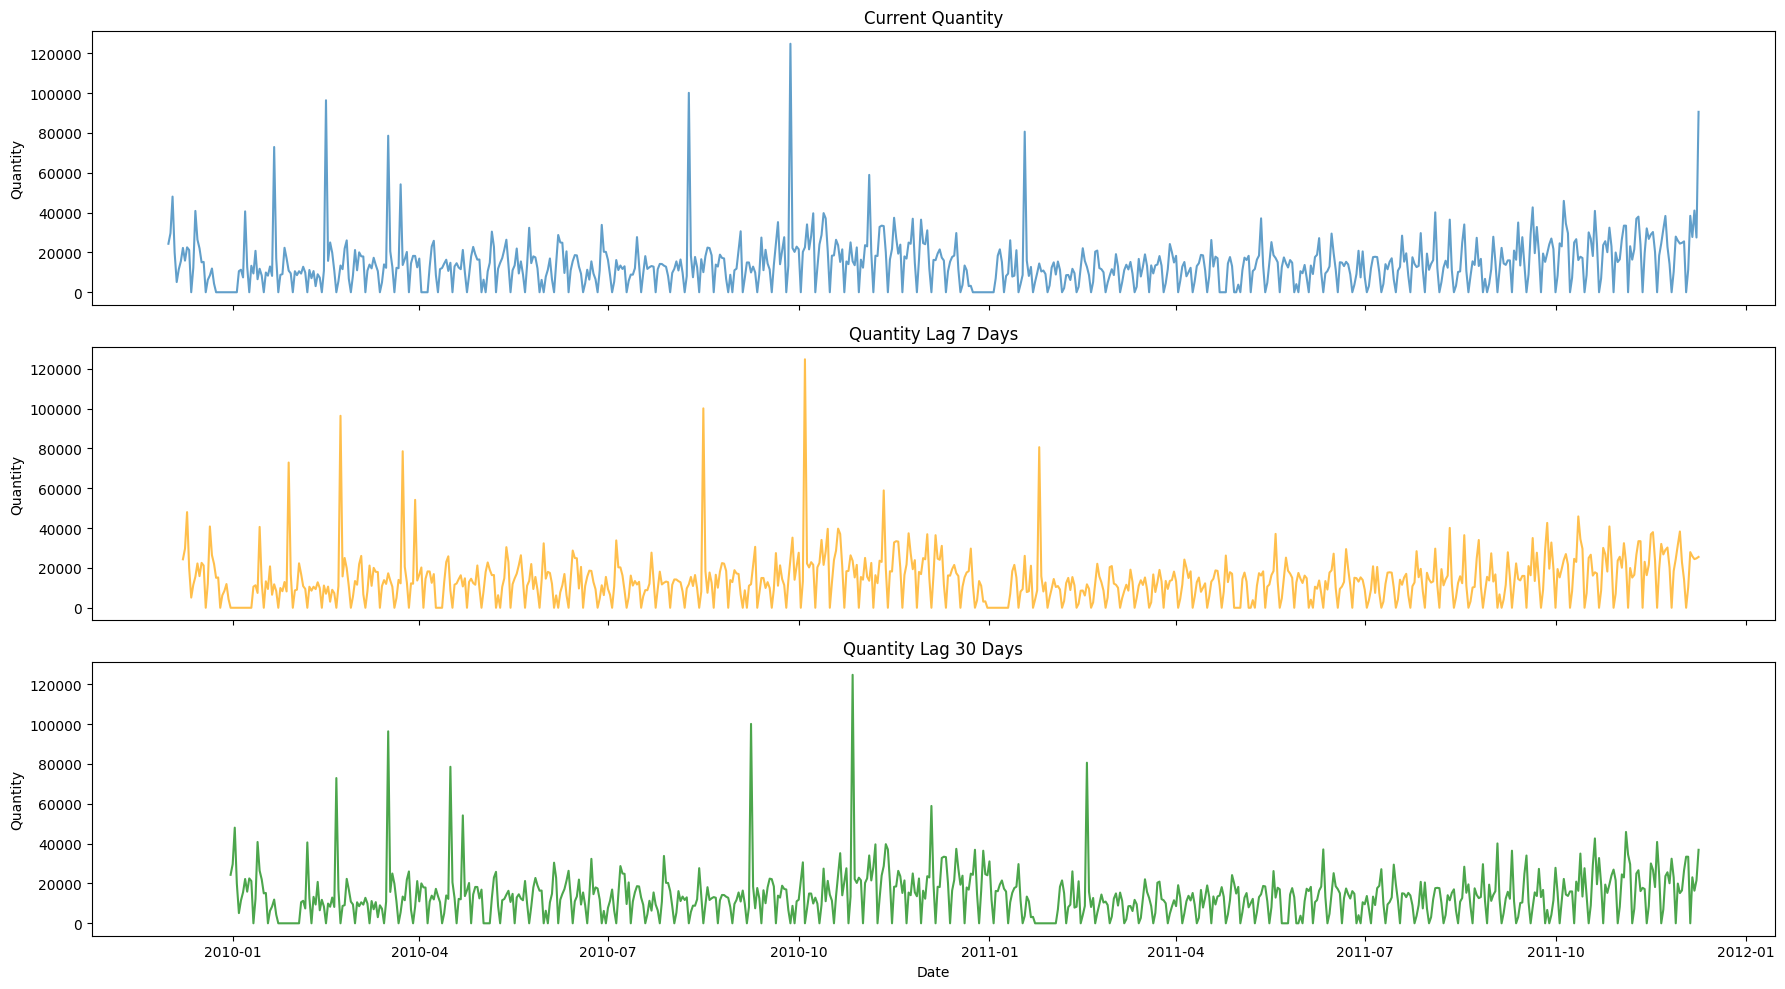

In [33]:
fig,axes = plt.subplots(3,1,figsize=(18,10),sharex=True)

axes[0].plot(daily_df["Date"],daily_df["DailyQuantity"],alpha=0.7)
axes[0].set_title("Current Quantity")
axes[0].set_ylabel("Quantity")

axes[1].plot(daily_df["Date"],daily_df["Quantity_Lag7"],alpha=0.7,color="orange")
axes[1].set_title("Quantity Lag 7 Days")
axes[1].set_ylabel("Quantity")

axes[2].plot(daily_df["Date"],daily_df["Quantity_Lag30"],alpha=0.7,color="green")
axes[2].set_title("Quantity Lag 30 Days")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Quantity")

plt.tight_layout()
plt.savefig("../Reports/Figure/4-Quantity_Lag_Comparison(2).png",dpi=300,bbox_inches="tight")
plt.show()

In [34]:
%pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.6 MB 3.3 MB/s eta 0:00:03
   ------- -------------------------------- 1.8/9.6 MB 3.8 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.6 MB 3.9 MB/s eta 0:00:02
   --------- ------------------------------ 2.4/9.6 MB 2.4 MB/s eta 0:00:04
   --------------- ------------------------ 3.7/9.6 MB 3.2 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.6 MB 3.3 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.6 MB 2.8 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.6 MB 3.0 MB/s eta 0:00:02
   -------------------------- ------------- 6.3/9.6 MB 3.2 MB/s eta 0:00:02
   --------------------------- ------------ 6.6/9.6 MB 3.1 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.6 MB 3.0 MB/s eta 0:00:01
   -----------------------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


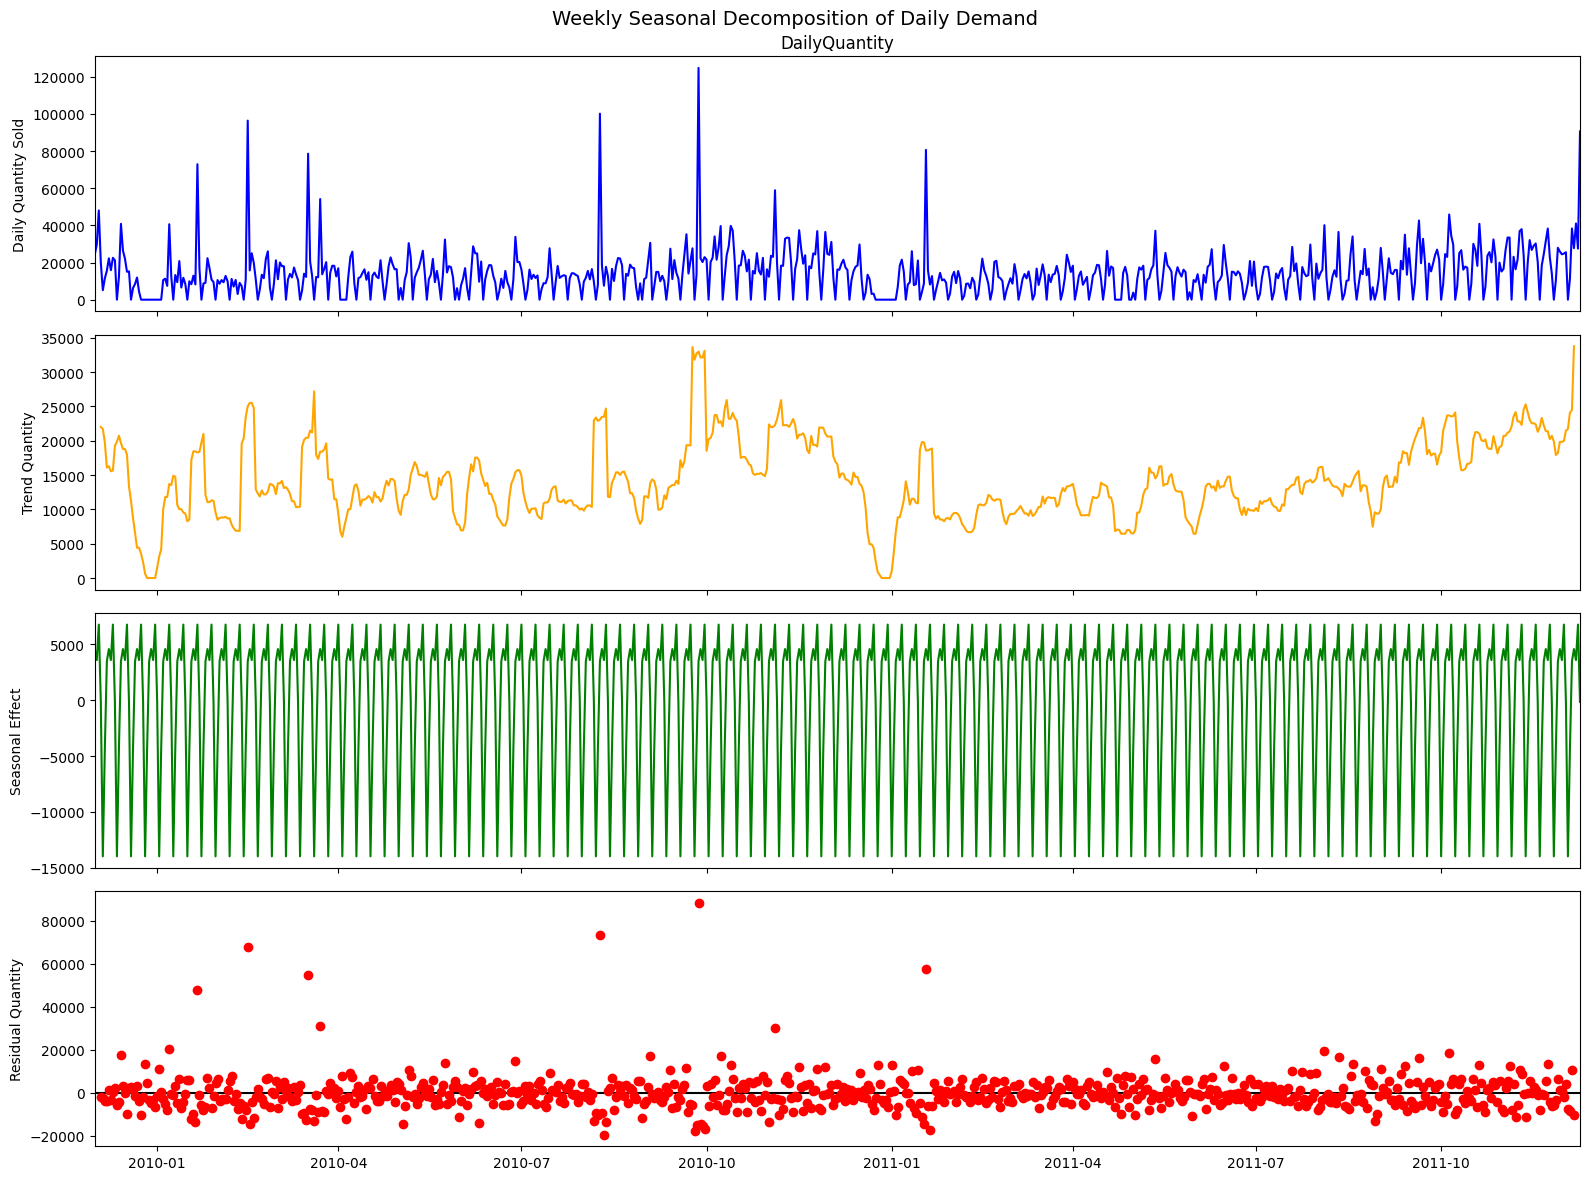

In [38]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(daily_df.set_index("Date")["DailyQuantity"],model="additive",period=7)

fig=decomposition.plot()
fig.set_size_inches(16,12)

axes=fig.axes
axes[0].set_ylabel("Daily Quantity Sold")
axes[1].set_ylabel("Trend Quantity")
axes[2].set_ylabel("Seasonal Effect")
axes[3].set_ylabel("Residual Quantity")

colors=["blue","orange","green","red"]

for ax,color in zip(axes,colors):
    ax.lines[0].set_color(color)

fig.suptitle("Weekly Seasonal Decomposition of Daily Demand",fontsize=14)
fig.tight_layout()
fig.savefig("../Reports/Figure/4-Seasonal_Decomposition.png",dpi=300,bbox_inches="tight")
plt.show()

In [39]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(daily_df["DailyQuantity"])

print("ADF Statistic:",adf_result[0])
print("P-Value:",adf_result[1])

if adf_result[1] < 0.05:
    print("Result: DailyQuantity is stationary.")
else:
    print("Result: DailyQuantity is not stationary.")

ADF Statistic: -2.986760346416699
P-Value: 0.03614945270088584
Result: DailyQuantity is stationary.


### ADF Stationarity Test Result

- ADF Statistic: `-2.9868`
- P-Value: `0.0361`
- Since the p-value is below `0.05`, the null hypothesis of non-stationarity is rejected.
- Therefore, the `DailyQuantity` time series is considered stationary and suitable for baseline forecasting.

### ADF Stationarity Test

The ADF test checks whether the time series is stationary or non-stationary.

We use the p-value to make the decision:

- `p-value < 0.05` → Stationary  
- `p-value >= 0.05` → Non-stationary  

In our case, the p-value is `0.0361`, so `DailyQuantity` is stationary.

In [40]:
daily_df.to_csv(process / "retail_daily_sales_timeseries.csv",index=False)